In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import re
from glob import glob
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns

In [ ]:

dataset_path = "/content/drive/MyDrive/Audio_project/HW1_M"

audio_files = glob(os.path.join(dataset_path, "*.mp3"))

file_data = []

filename_pattern = re.compile(r"HW\d+_Q\d+_(\d+)_(male|female)", re.IGNORECASE)

for file_path in audio_files:
    filename = os.path.basename(file_path)
    match = filename_pattern.match(filename)

    if match:
        student_id, gender = match.groups()
        file_data.append([filename, file_path, student_id, gender.lower()])

df_audio = pd.DataFrame(file_data, columns=["Filename", "Filepath", "Student_ID", "Gender"])

df_audio.head()

,Filename,Filepath,Student_ID,Gender
0,HW1_Q5_810801072_Male.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,810801072,male
1,HW1_Q3_810103262_male.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,810103262,male
2,HW1_Q6_810600133_female.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,810600133,female
3,HW1_Q4_159403005_male.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,159403005,male
4,HW1_Q1_810102345_male.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,810102345,male


In [ ]:
male_data = df_audio[df_audio["Gender"] == "male"]
female_data = df_audio[df_audio["Gender"] == "female"]

print("Number of Male Audio Files:", len(male_data))
print("Number of Female Audio Files:", len(female_data))

Number of Male Audio Files: 458
Number of Female Audio Files: 152


In [ ]:
grouped_by_student = df_audio[["Student_ID", "Filename"]].groupby("Student_ID").count().reset_index().sort_values("Filename", ascending=False)

print("Number of Unique Students:", len(grouped_by_student))

grouped_by_student = grouped_by_student.rename({"Filename": "Number of Files"}, axis = 1)
grouped_by_student

Number of Unique Students: 107


,Student_ID,Number of Files
6,610399205,7
0,151501033,6
63,810103140,6
74,810103241,6
72,810103222,6
...,...,...
87,810198554,4
93,810199459,3
75,810103262,3
73,810103224,3


In [ ]:
from tqdm import tqdm
tqdm.pandas()

def bandpass_filter(y, sr, lowcut=80.0 , highcut=3500.0, order=5):
    nyquist = 0.5 * sr
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y_filtered = lfilter(b, a, y)
    return y_filtered

def normalize_audio(y):
    return y / np.max(np.abs(y))

def segment_audio(y, sr, segment_length=2.0):
    segment_samples = int(segment_length * sr)
    return [y[i:i + segment_samples] for i in range(0, len(y), segment_samples) if len(y[i:i + segment_samples]) == segment_samples]

def preprocess_and_extract_features(file_path, n_mfcc=40, segment_length=2.0, target_sr=16000, max_length=60):

    y, sr = librosa.load(file_path, sr=None, duration=max_length)
    y = bandpass_filter(y, sr)
    y = resample(y, int(len(y) * target_sr / sr))
    sr = target_sr
    y = normalize_audio(y)
    segments = segment_audio(y, sr, segment_length)

    features = []
    for segment in segments:
        mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=n_mfcc).mean(axis=1)
        zcr = librosa.feature.zero_crossing_rate(segment).mean()
        rms = librosa.feature.rms(y=segment).mean()
        spectral_centroid = librosa.feature.spectral_centroid(y=segment, sr=sr).mean()
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=segment, sr=sr).mean()
        spectral_contrast = librosa.feature.spectral_contrast(y=segment, sr=sr).mean()
        features.append(np.hstack([mfcc, zcr, rms, spectral_centroid, spectral_bandwidth, spectral_contrast]))

    return np.array(features)

def balance_dataset(df):
    male_data = df[df["Gender"] == "male"]
    female_data = df[df["Gender"] == "female"]
    balanced_male_data = male_data.sample(len(female_data), random_state=42)
    balanced_df = pd.concat([balanced_male_data, female_data]).reset_index(drop=True)
    return balanced_df

def process_all_files(df, segment_length=2.0, target_sr=16000, max_length=60):
    features = []
    labels = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing files"):
        file_path = row["Filepath"]
        label = 1 if row["Gender"] == "female" else 0
        try:
            file_features = preprocess_and_extract_features(file_path, segment_length=segment_length, target_sr=target_sr, max_length=max_length)
            for feature in file_features:
                features.append(feature)
                labels.append(label)
        except Exception as e:
            print(f"Error processing file {file_path}: {e}")
    return np.array(features), np.array(labels)

In [ ]:
sample_file_path = df_audio.iloc[0]["Filepath"]
sample_features = preprocess_and_extract_features(sample_file_path)

print(f"Extracted Features Shape: {sample_features.shape}")

Extracted Features Shape: (30, 45)


In [ ]:
def select_random_voices(df, num_samples=3):
    return df.groupby("Student_ID", group_keys=False).apply(lambda x: x.sample(n=min(len(x), num_samples), random_state=42))

filtered_df_audio = select_random_voices(df_audio)
balanced_df = balance_dataset(filtered_df_audio)

id_gender_df = balanced_df[['Student_ID', 'Gender']].drop_duplicates()
train_ids, test_ids = train_test_split(id_gender_df['Student_ID'],  test_size=0.25, random_state=42, stratify=id_gender_df['Gender'])

train_df = balanced_df[balanced_df['Student_ID'].isin(train_ids)]
test_df = balanced_df[balanced_df['Student_ID'].isin(test_ids)]

assert len(set(train_df['Student_ID']).intersection(set(test_df['Student_ID']))) == 0, "ID Overlap detected!"

<ipython-input-9-a5b6132adbae>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("Student_ID", group_keys=False).apply(lambda x: x.sample(n=min(len(x), num_samples), random_state=42))


In [ ]:
X_train, y_train = process_all_files(train_df)
X_test, y_test = process_all_files(test_df)

Processing files: 100%|██████████| 42/42 [00:57<00:00,  1.38s/it]


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2.7 CLUSTERING

### combine the train and test data into a single dataset

In [ ]:
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

X.shape, y.shape

((4858, 45), (4858,))

### visualize the dataset

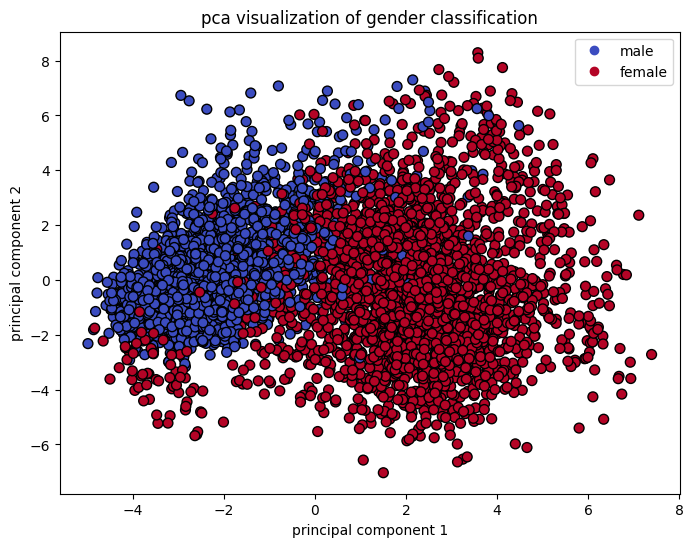

In [ ]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
tmp = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.title('pca visualization of gender classification')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.legend(handles=tmp.legend_elements()[0], labels=['male', 'female'])
plt.show()

### cluster the data using two different methods: KMeans and Agglomerative
(original feature space)



In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

n_clusters = 2 # assuming 2 clusters based on gender
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)
agg_labels = agg_clustering.fit_predict(X)

kmeans_silhouette = silhouette_score(X, kmeans_labels)
agg_silhouette = silhouette_score(X, agg_labels)

print(f'\nKMeans Silhouette-Score: {kmeans_silhouette:.3f}')
print(f'Agglomerative Silhouette-Score: {agg_silhouette:.3f}\n')


KMeans Silhouette-Score: 0.131
Agglomerative Silhouette-Score: 0.123



### find the optimal number of principal components for clustering

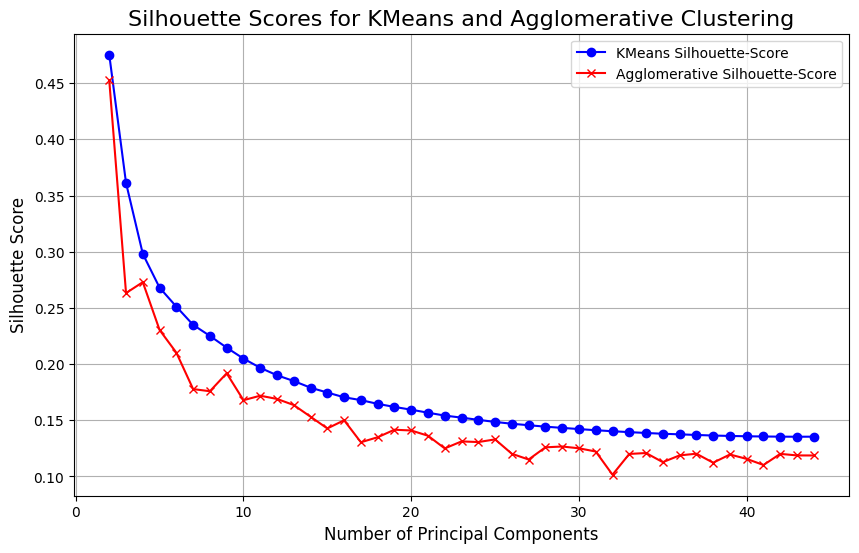

In [ ]:
kmeans_silhouettes = []
agg_silhouettes = []

n_components_range = range(2, 45)

for n_components in n_components_range:

    pca = PCA(n_components=n_components)
    X_reduced = pca.fit_transform(X)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_reduced)
    kmeans_silhouette = silhouette_score(X_reduced, kmeans_labels)
    kmeans_silhouettes.append(kmeans_silhouette)

    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)
    agg_labels = agg_clustering.fit_predict(X_reduced)
    agg_silhouette = silhouette_score(X_reduced, agg_labels)
    agg_silhouettes.append(agg_silhouette)

plt.figure(figsize=(10, 6))
plt.plot(n_components_range, kmeans_silhouettes, label='KMeans Silhouette-Score', color='blue', marker='o')
plt.plot(n_components_range, agg_silhouettes, label='Agglomerative Silhouette-Score', color='red', marker='x')

plt.title('Silhouette Scores for KMeans and Agglomerative Clustering', fontsize=16)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.legend(loc='best')
plt.grid(True)
plt.show()

### KMeans and Agglomerative clustering
(reduced feature space (2D))


KMeans Silhouette-Score: 0.457
Agglomerative Silhouette-Score: 0.438



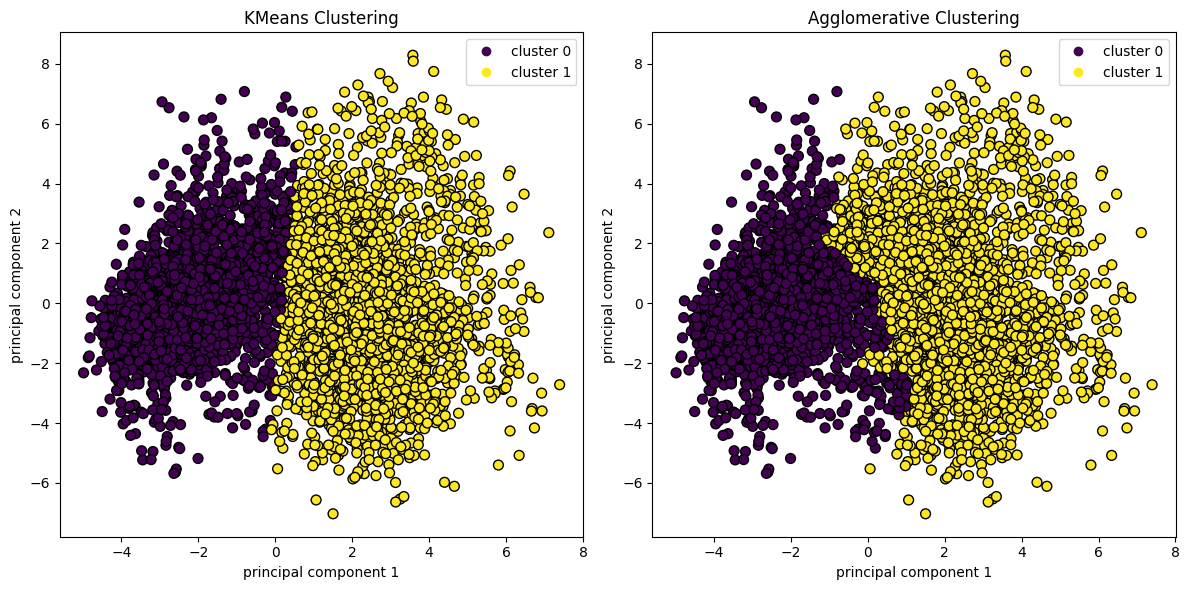

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

n_clusters = 2 # assuming 2 clusters based on gender
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(X_2d)

agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)
agg_labels = agg_clustering.fit_predict(X_2d)

kmeans_silhouette = silhouette_score(X_2d, kmeans_labels)
agg_silhouette = silhouette_score(X_2d, agg_labels)

print(f'\nKMeans Silhouette-Score: {kmeans_silhouette:.3f}')
print(f'Agglomerative Silhouette-Score: {agg_silhouette:.3f}\n')


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

tmp = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=1-kmeans_labels, cmap='viridis', edgecolor='k', s=50)
plt.title('KMeans Clustering')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.legend(handles=tmp.legend_elements()[0], labels=['cluster 0', 'cluster 1'])

plt.subplot(1, 2, 2)
tmp = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=1-agg_labels, cmap='viridis', edgecolor='k', s=50)
plt.title('Agglomerative Clustering')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.legend(handles=tmp.legend_elements()[0], labels=['cluster 0', 'cluster 1'])

plt.tight_layout()
plt.show()

### find the optimal number of clusters

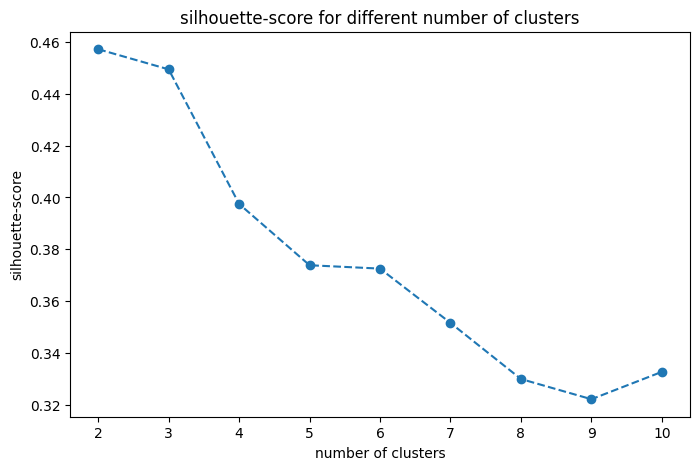

In [ ]:
n_clusters_range = range(2, 11)
silhouette_scores = []

for k in n_clusters_range:
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X_2d)
    score = silhouette_score(X_2d, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(n_clusters_range, silhouette_scores, marker='o', linestyle='--')
plt.xlabel('number of clusters')
plt.ylabel('silhouette-score')
plt.title('silhouette-score for different number of clusters')
plt.show()

### KMeans and Agglomerative clustering
(number of clusters = 5)


KMeans Silhouette-Score: 0.373
Agglomerative Silhouette-Score: 0.285



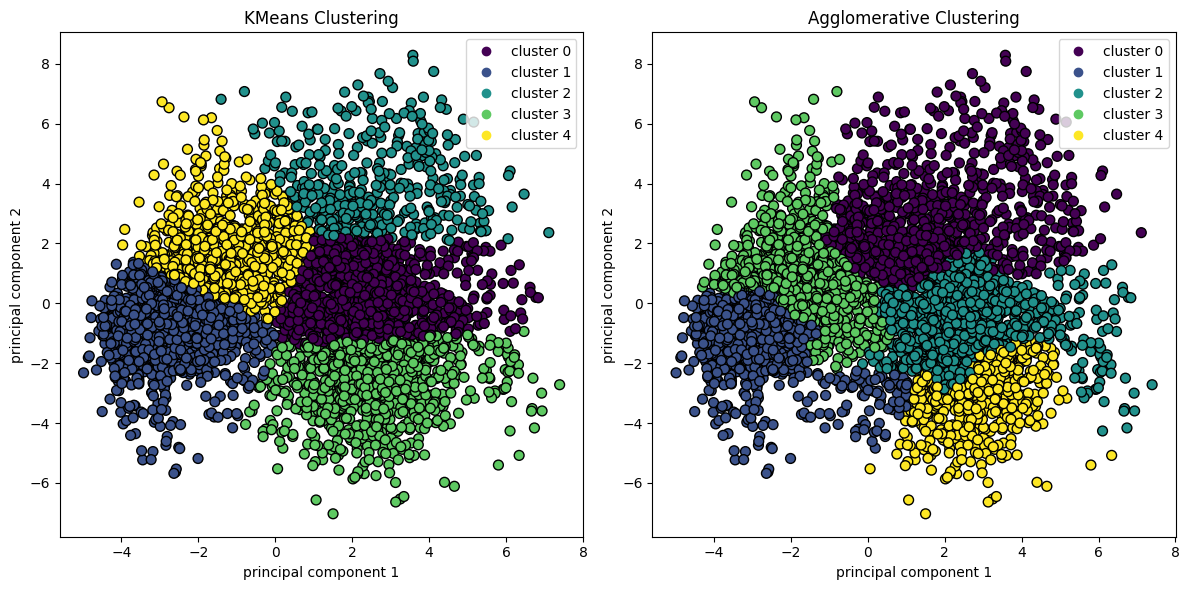

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(X_2d)

agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)
agg_labels = agg_clustering.fit_predict(X_2d)

kmeans_silhouette = silhouette_score(X_2d, kmeans_labels)
agg_silhouette = silhouette_score(X_2d, agg_labels)

print(f'\nKMeans Silhouette-Score: {kmeans_silhouette:.3f}')
print(f'Agglomerative Silhouette-Score: {agg_silhouette:.3f}\n')


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

tmp = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels, cmap='viridis', edgecolor='k', s=50)
plt.title('KMeans Clustering')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.legend(handles=tmp.legend_elements()[0], labels=[f'cluster {i}' for i in range(n_clusters)])

plt.subplot(1, 2, 2)
tmp = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=agg_labels, cmap='viridis', edgecolor='k', s=50)
plt.title('Agglomerative Clustering')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.legend(handles=tmp.legend_elements()[0], labels=[f'cluster {i}' for i in range(n_clusters)])

plt.tight_layout()
plt.show()

### KMeans and Agglomerative clustering
(number of clusters = 8)


KMeans Silhouette-Score: 0.331
Agglomerative Silhouette-Score: 0.283



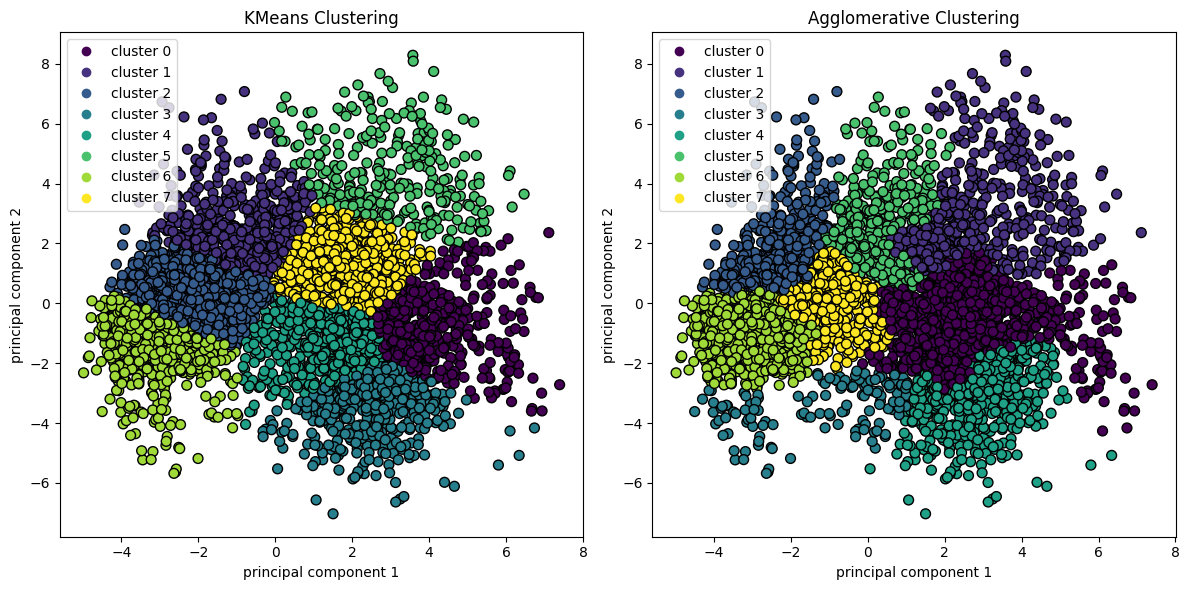

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(X_2d)

agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)
agg_labels = agg_clustering.fit_predict(X_2d)

kmeans_silhouette = silhouette_score(X_2d, kmeans_labels)
agg_silhouette = silhouette_score(X_2d, agg_labels)

print(f'\nKMeans Silhouette-Score: {kmeans_silhouette:.3f}')
print(f'Agglomerative Silhouette-Score: {agg_silhouette:.3f}\n')


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

tmp = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels, cmap='viridis', edgecolor='k', s=50)
plt.title('KMeans Clustering')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.legend(handles=tmp.legend_elements()[0], labels=[f'cluster {i}' for i in range(n_clusters)])

plt.subplot(1, 2, 2)
tmp = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=agg_labels, cmap='viridis', edgecolor='k', s=50)
plt.title('Agglomerative Clustering')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.legend(handles=tmp.legend_elements()[0], labels=[f'cluster {i}' for i in range(n_clusters)])

plt.tight_layout()
plt.show()

### clusters vs. true labels

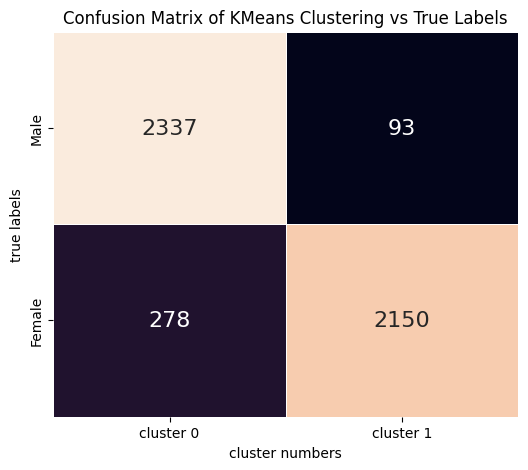

In [ ]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(X_2d)

conf_matrix = confusion_matrix(y, 1-kmeans_labels)

conf_matrix_df = pd.DataFrame(conf_matrix, columns=['cluster 0', 'cluster 1'], index=['Male', 'Female'])

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cbar=False, annot_kws={'size': 16}, linewidths=0.5)

plt.title('Confusion Matrix of KMeans Clustering vs True Labels', fontsize=12)
plt.xlabel('cluster numbers', fontsize=10)
plt.ylabel('true labels', fontsize=10)
plt.show()

### accuracy of gender classification in clustering

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, 1-kmeans_labels)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9236
